In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              roc_curve,
                              roc_auc_score,
                              accuracy_score,
                              precision_score,
                              recall_score,
                              f1_score)
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials ─────────────────────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ────────────────────────────────────────────
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
os.makedirs(VISUALS, exist_ok=True)

# ── Database connection ──────────────────────────────
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1119, 20)


In [2]:
print("="*55)
print("TARGET VARIABLE — is_fatal")
print("="*55)
print(f"\nTotal records       : {len(df)}")
print(f"Missing is_fatal    : {df['is_fatal'].isnull().sum()}")
print()
print("Class distribution:")
print(df['is_fatal'].value_counts())
print()
fatal_rate = df['is_fatal'].mean() * 100
print(f"Fatal accidents     : {df['is_fatal'].sum()}")
print(f"Non-fatal accidents : {(df['is_fatal']==0).sum()}")
print(f"Fatal rate          : {fatal_rate:.1f}%")
print()
if fatal_rate < 30:
    print("NOTE: Dataset is IMBALANCED")
    print("Fatal accidents are the minority class")
    print("We will use class_weight='balanced' to handle this")

TARGET VARIABLE — is_fatal

Total records       : 1119
Missing is_fatal    : 0

Class distribution:
is_fatal
0    1079
1      40
Name: count, dtype: int64

Fatal accidents     : 40
Non-fatal accidents : 1079
Fatal rate          : 3.6%

NOTE: Dataset is IMBALANCED
Fatal accidents are the minority class
We will use class_weight='balanced' to handle this


In [3]:
# ── Fill nulls before encoding ───────────────────────
df['county']          = df['county'].fillna('Unknown')
df['cause_code']      = df['cause_code'].fillna('Unknown')
df['victim_category'] = df['victim_category'].fillna('Unknown')
df['time_of_day']     = df['time_of_day'].fillna('Unknown')
df['hour']            = df['hour'].fillna(0)
df['num_victims']     = df['num_victims'].fillna(1)

# ── Encode categorical columns ───────────────────────
le_county  = LabelEncoder()
le_cause   = LabelEncoder()
le_victim  = LabelEncoder()
le_time    = LabelEncoder()

df['county_encoded']  = le_county.fit_transform(df['county'])
df['cause_encoded']   = le_cause.fit_transform(
                         df['cause_code'].astype(str))
df['victim_encoded']  = le_victim.fit_transform(df['victim_category'])
df['time_encoded']    = le_time.fit_transform(df['time_of_day'])

print("Encoding complete")
print(f"\nCounty categories  : {len(le_county.classes_)}")
print(f"Cause categories   : {len(le_cause.classes_)}")
print(f"Victim categories  : {len(le_victim.classes_)}")
print(f"Time categories    : {len(le_time.classes_)}")

Encoding complete

County categories  : 43
Cause categories   : 74
Victim categories  : 7
Time categories    : 5


In [4]:
# ── Define features and target ───────────────────────
features = [
    'hour',
    'county_encoded',
    'cause_encoded',
    'victim_encoded',
    'time_encoded',
    'num_victims'
]

feature_names = [
    'Hour of Day',
    'County',
    'Cause Code',
    'Victim Type',
    'Time of Day',
    'Number of Victims'
]

# Drop rows with missing target
df_model = df[features + ['is_fatal']].dropna()

X = df_model[features]
y = df_model['is_fatal']

print("="*55)
print("MODEL DATASET SUMMARY")
print("="*55)
print(f"Total records     : {len(df_model)}")
print(f"Features          : {len(features)}")
print(f"Target variable   : is_fatal (0=Not Fatal, 1=Fatal)")
print(f"\nClass balance:")
print(f"  Not Fatal (0)   : {(y==0).sum()}")
print(f"  Fatal     (1)   : {(y==1).sum()}")
print(f"  Fatal rate      : {y.mean()*100:.1f}%")

MODEL DATASET SUMMARY
Total records     : 1119
Features          : 6
Target variable   : is_fatal (0=Not Fatal, 1=Fatal)

Class balance:
  Not Fatal (0)   : 1079
  Fatal     (1)   : 40
  Fatal rate      : 3.6%


In [5]:
# ── Split 80/20 with stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y    # preserves fatal/non-fatal ratio
)

print("="*55)
print("TRAIN / TEST SPLIT")
print("="*55)
print(f"Training samples  : {len(X_train)}")
print(f"Testing samples   : {len(X_test)}")
print()
print("Training class distribution:")
print(y_train.value_counts())
print()
print("Testing class distribution:")
print(y_test.value_counts())

TRAIN / TEST SPLIT
Training samples  : 895
Testing samples   : 224

Training class distribution:
is_fatal
0    863
1     32
Name: count, dtype: int64

Testing class distribution:
is_fatal
0    216
1      8
Name: count, dtype: int64


In [6]:
# ── Train Logistic Regression ────────────────────────
# class_weight='balanced' handles class imbalance
# max_iter=1000 ensures the model fully converges

model = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42
)
model.fit(X_train, y_train)

# ── Make predictions ─────────────────────────────────
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
# [:, 1] gets the probability of being Fatal (class 1)

print("Model trained successfully")
print()
print("Sample predictions:")
print(f"{'Actual':<10} {'Predicted':<12} {'Probability':<12}")
print("-"*34)
for actual, pred, prob in zip(
    y_test.values[:10],
    y_pred[:10],
    y_pred_proba[:10]
):
    label = "FATAL" if pred == 1 else "Not Fatal"
    print(f"{actual:<10} {label:<12} {prob:.3f}")

Model trained successfully

Sample predictions:
Actual     Predicted    Probability 
----------------------------------
0          Not Fatal    0.367
1          FATAL        0.655
0          Not Fatal    0.417
0          FATAL        0.773
0          FATAL        0.565
0          FATAL        0.554
0          Not Fatal    0.406
0          Not Fatal    0.192
0          Not Fatal    0.447
0          FATAL        0.624


In [7]:
# ── Full evaluation metrics ──────────────────────────
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)
auc   = roc_auc_score(y_test, y_pred_proba)

print("="*55)
print("MODEL EVALUATION — LOGISTIC REGRESSION")
print("="*55)
print(f"Accuracy   : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
print()
print("Full Classification Report:")
print("-"*55)
print(classification_report(
    y_test, y_pred,
    target_names=['Not Fatal', 'Fatal'],
    zero_division=0
))

MODEL EVALUATION — LOGISTIC REGRESSION
Accuracy   : 0.6161  (61.6%)
Precision  : 0.0465
Recall     : 0.5000
F1 Score   : 0.0851
AUC-ROC    : 0.5469

Full Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

   Not Fatal       0.97      0.62      0.76       216
       Fatal       0.05      0.50      0.09         8

    accuracy                           0.62       224
   macro avg       0.51      0.56      0.42       224
weighted avg       0.94      0.62      0.73       224



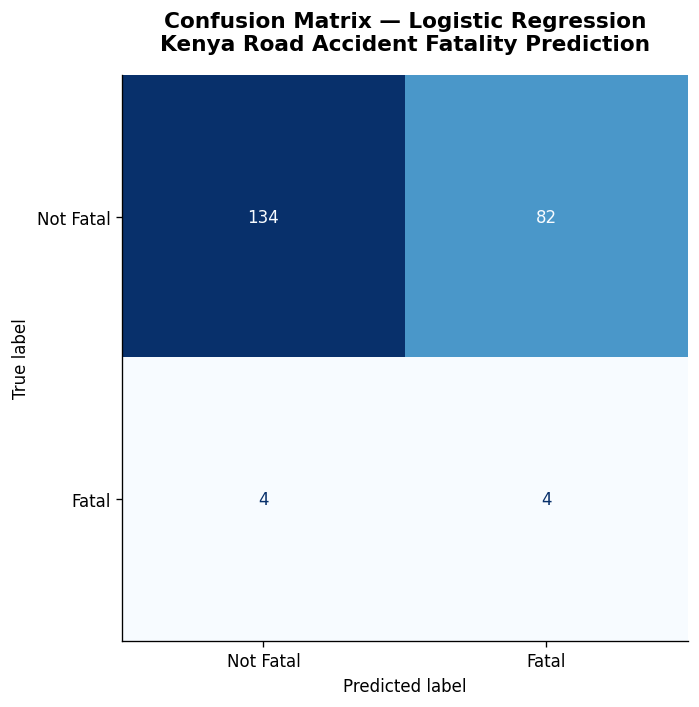

Confusion Matrix Breakdown:
  Correctly predicted Not Fatal : 134
  Correctly predicted Fatal     : 4
  False alarms (predicted Fatal,
    actually Not Fatal)          : 82
  Missed fatals (predicted Not
    Fatal, actually Fatal)       : 4


In [8]:
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Not Fatal', 'Fatal']
)
disp.plot(cmap='Blues', colorbar=False, ax=ax)

ax.set_title('Confusion Matrix — Logistic Regression\n'
             'Kenya Road Accident Fatality Prediction',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'log_confusion_matrix.png'),
            bbox_inches='tight')
plt.show()

print("Confusion Matrix Breakdown:")
print(f"  Correctly predicted Not Fatal : {tn}")
print(f"  Correctly predicted Fatal     : {tp}")
print(f"  False alarms (predicted Fatal,")
print(f"    actually Not Fatal)          : {fp}")
print(f"  Missed fatals (predicted Not")
print(f"    Fatal, actually Fatal)       : {fn}")

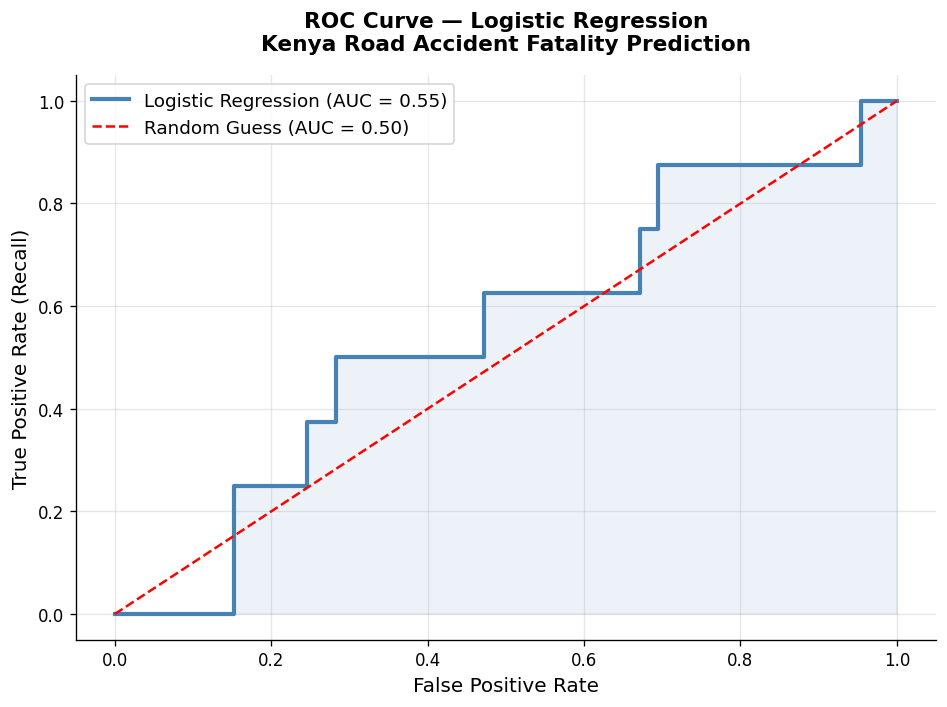

AUC Score: 0.5469
Chart saved


In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr,
        color='steelblue', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc:.2f})')
ax.plot([0, 1], [0, 1],
        color='red', linewidth=1.5,
        linestyle='--', label='Random Guess (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

ax.set_title('ROC Curve — Logistic Regression\n'
             'Kenya Road Accident Fatality Prediction',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'log_roc_curve.png'),
            bbox_inches='tight')
plt.show()
print(f"AUC Score: {auc:.4f}")
print("Chart saved")

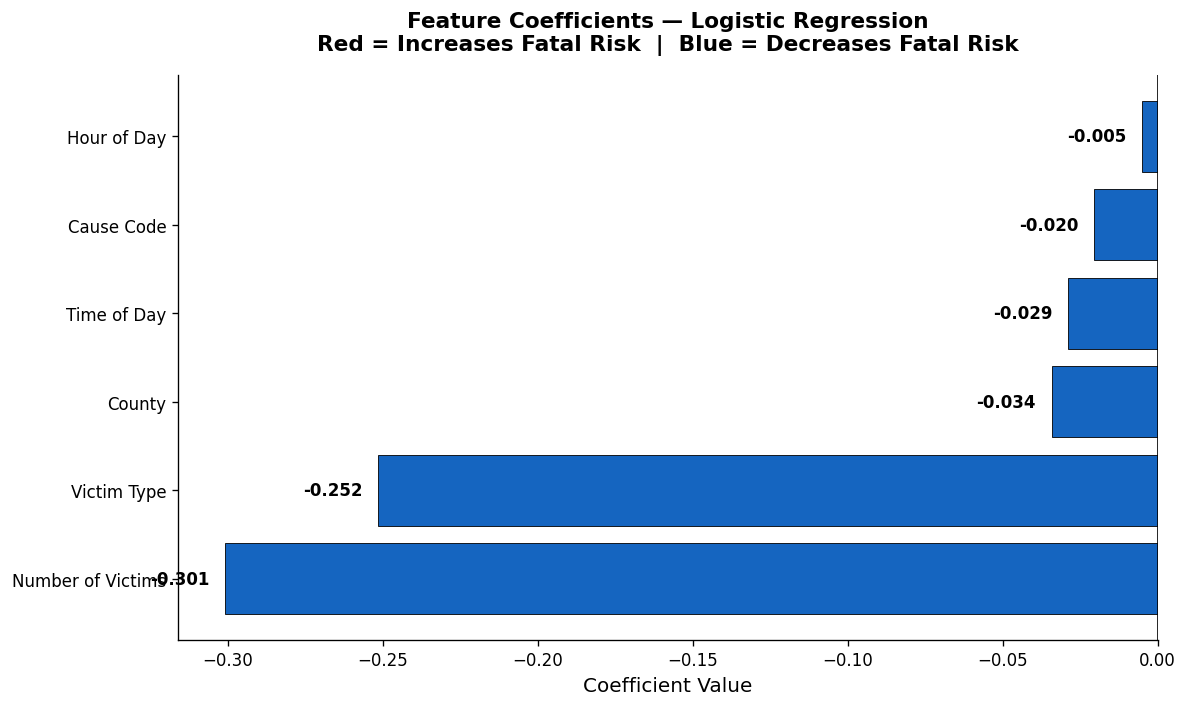

Chart saved


In [10]:
coeff_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = [
    '#BB0000' if c > 0 else '#1565C0'
    for c in coeff_df['Coefficient']
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    coeff_df['Feature'],
    coeff_df['Coefficient'],
    color=colors,
    edgecolor='black', linewidth=0.5
)

for bar, val in zip(bars, coeff_df['Coefficient']):
    ax.text(
        bar.get_width() + 0.005
        if val >= 0 else bar.get_width() - 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10, fontweight='bold'
    )

ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Feature Coefficients — Logistic Regression\n'
             'Red = Increases Fatal Risk  |  '
             'Blue = Decreases Fatal Risk',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Coefficient Value', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'log_coefficients.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

In [11]:
def predict_fatality(hour, county, cause,
                     victim, time_of_day,
                     num_victims):
    try:
        input_data = pd.DataFrame([{
            'hour'           : hour,
            'county_encoded' : le_county.transform(
                                [county])[0],
            'cause_encoded'  : le_cause.transform(
                                [str(cause)])[0],
            'victim_encoded' : le_victim.transform(
                                [victim])[0],
            'time_encoded'   : le_time.transform(
                                [time_of_day])[0],
            'num_victims'    : num_victims
        }])

        prediction   = model.predict(input_data)[0]
        probability  = model.predict_proba(
                           input_data)[0][1]

        if probability >= 0.75:
            risk = "CRITICAL RISK"
            color_label = "RED"
        elif probability >= 0.50:
            risk = "HIGH RISK"
            color_label = "ORANGE"
        elif probability >= 0.25:
            risk = "MEDIUM RISK"
            color_label = "YELLOW"
        else:
            risk = "LOW RISK"
            color_label = "GREEN"

        print("="*52)
        print("  KENYA ROAD ACCIDENT FATALITY PREDICTION")
        print("  Logistic Regression Model")
        print("="*52)
        print(f"  County        : {county}")
        print(f"  Time          : {hour:02d}:00 ({time_of_day})")
        print(f"  Cause Code    : {cause}")
        print(f"  Victim Type   : {victim}")
        print(f"  Num Victims   : {num_victims}")
        print("-"*52)
        print(f"  Fatal Prob    : {probability*100:.1f}%")
        print(f"  Prediction    : "
              f"{'FATAL' if prediction==1 else 'NOT FATAL'}")
        print(f"  Risk Level    : {risk}")
        print("="*52)

    except ValueError as e:
        print(f"Input error: {e}")

# ── Test with two scenarios ──────────────────────────
print("SCENARIO 1 — Night accident, Nairobi, Speeding")
predict_fatality(
    hour        = 22,
    county      = 'NAIROBI',
    cause       = '10',
    victim      = 'Motorcyclist',
    time_of_day = 'Night',
    num_victims = 1
)

print()
print("SCENARIO 2 — Morning accident, Mombasa")
predict_fatality(
    hour        = 8,
    county      = 'MOMBASA',
    cause       = '26',
    victim      = 'Pedestrian',
    time_of_day = 'Morning',
    num_victims = 1
)

SCENARIO 1 — Night accident, Nairobi, Speeding
  KENYA ROAD ACCIDENT FATALITY PREDICTION
  Logistic Regression Model
  County        : NAIROBI
  Time          : 22:00 (Night)
  Cause Code    : 10
  Victim Type   : Motorcyclist
  Num Victims   : 1
----------------------------------------------------
  Fatal Prob    : 64.5%
  Prediction    : FATAL
  Risk Level    : HIGH RISK

SCENARIO 2 — Morning accident, Mombasa
  KENYA ROAD ACCIDENT FATALITY PREDICTION
  Logistic Regression Model
  County        : MOMBASA
  Time          : 08:00 (Morning)
  Cause Code    : 26
  Victim Type   : Pedestrian
  Num Victims   : 1
----------------------------------------------------
  Fatal Prob    : 42.7%
  Prediction    : NOT FATAL
  Risk Level    : MEDIUM RISK


In [12]:
print("="*55)
print("NOTEBOOK 5 COMPLETE — LOGISTIC REGRESSION")
print("="*55)
print(f"\nModel         : Logistic Regression")
print(f"Target        : is_fatal (0=Not Fatal, 1=Fatal)")
print(f"Features used : {len(features)}")
print(f"Training size : {len(X_train)}")
print(f"Testing size  : {len(X_test)}")
print()
print("Evaluation Results:")
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1 Score   : {f1:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print()
print("Charts saved:")
print("  log_confusion_matrix.png")
print("  log_roc_curve.png")
print("  log_coefficients.png")
print()
print("Next → Notebook 6: Decision Tree")

NOTEBOOK 5 COMPLETE — LOGISTIC REGRESSION

Model         : Logistic Regression
Target        : is_fatal (0=Not Fatal, 1=Fatal)
Features used : 6
Training size : 895
Testing size  : 224

Evaluation Results:
  Accuracy   : 0.6161
  Precision  : 0.0465
  Recall     : 0.5000
  F1 Score   : 0.0851
  AUC-ROC    : 0.5469

Charts saved:
  log_confusion_matrix.png
  log_roc_curve.png
  log_coefficients.png

Next → Notebook 6: Decision Tree
